In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from setup import train, device, train_test_split_path, accuracy, plot_losses, Image_dataset, get_data_max, train_pro_max, Sequence_dataset
X_train_path, X_test_path, X_eval_path, y_train, y_test, y_eval = train_test_split_path()

Usando dispositivo: cuda


In [19]:
# Parametros en general por limitaciones de hardware
BATCH_SIZES = {
    'mel': 8,
    'mfcc': 16,
    'cqt': 16,
    'wav2vec2': 4,
    'EnCodecMAE': 8
}

LEARNING_RATES = {
    'mel': 0.0001,#0.001,
    'mfcc': 0.0009,#0.0039,
    'cqt': 0.0009,#0.0039,
    'wav2vec2': 0.00001,#0.0009,
    'EnCodecMAE': 0.0001
}

### CNN2d
Mfcc y wav2vec2 deberian dar malos resultados porque sus embedding son casi independientes entre si, tiene mas sentido usarlos con conv1d

In [3]:
class CNN1(nn.Module):
    def __init__(self):
        super().__init__()
        # (B,1 ,80,3001) → Conv → LeakyReLU → Pool → (B,32,40,1500)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        # (B,32,40,1500) → Conv → LeakyReLU → Pool → (B,64,20,750)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        # (B,64,20,750) → Conv → LeakyReLU → Pool → (B,128,10,375)
        #self.conv3 = nn.Conv2d(in_channels=50, out_channels=50, kernel_size=3, stride=1, padding=1)
        # Global pooling to collapse spatial dims → (B,128,1,1)
        self.global_pool = nn.AdaptiveAvgPool2d((1,1))

        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.unsqueeze(1) # add channel dimension for Conv2d (B,80,3001) -> (B,1,80,3001)

        x = F.leaky_relu(self.conv1(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)

        x = F.leaky_relu(self.conv2(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        #x = F.leaky_relu(self.conv3(x))
        #x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        x = self.global_pool(x)
        
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        
        return self.fc1(x)

In [4]:
# Definimos hiperparámetros
NUM_EPOCHS = {
    'mel': 400,
    'mfcc': 0,
    'cqt': 300,
    'wav2vec2': 0,
    'EnCodecMAE': 0
}
params = {
    'num_epoths': NUM_EPOCHS,
    'batch_sizes': BATCH_SIZES,
    'learning_rates': LEARNING_RATES
}

train_losses, test_losses, accur = {}, {}, {} # PARA EL SUMMARY

#### Mel

In [5]:
FEATURE = 'mel'
MODEL = CNN1

train_dataset, test_dataset = get_data_max(FEATURE, Image_dataset)

# Entrenamos el modelo
model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
    model_class=MODEL,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    feature_name=FEATURE, 
    **params
)
accur[FEATURE] = accuracy(model0, test_dataset)

Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[-23.8628,  -9.3174,  -6.4540,  ..., -73.3293, -65.8977, -54.4696],
        [-22.0908,  -4.1262,  -3.4861,  ..., -66.0889, -62.7450, -53.7704],
        [-25.7104,  -4.2807,  -6.4059,  ..., -63.6177, -62.2644, -51.5204],
        ...,
        [-80.0000, -67.7903, -60.2403,  ..., -80.0000, -80.0000, -76.8562],
        [-80.0000, -76.9833, -68.9733,  ..., -80.0000, -80.0000, -76.2964],
        [-80.0000, -80.0000, -80.0000,  ..., -80.0000, -80.0000, -76.2242]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (80, 3001), 'target_length': 10}
--------------------------------------------------
Modelo creado con 19466 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/400
  

In [6]:
torch.save(model0.state_dict(), "../Models/modelo1_cnn_mel.pth")

#### Cqt

In [7]:
FEATURE = 'cqt'
MODEL = CNN1

train_dataset, test_dataset = get_data_max(FEATURE, Image_dataset)

# Entrenamos el modelo
model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
    model_class=MODEL,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    feature_name=FEATURE, 
    **params
)
accur[FEATURE] = accuracy(model0, test_dataset)

Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[-28.6540, -27.9601, -27.5905,  ..., -71.7345, -71.6110, -71.9175],
        [-23.5845, -22.4260, -21.5936,  ..., -73.9189, -74.3702, -74.8183],
        [-20.2321, -18.8270, -17.8161,  ..., -80.0000, -80.0000, -80.0000],
        ...,
        [-46.4007, -34.6097, -42.5703,  ..., -42.2461, -39.9783, -50.7851],
        [-45.0566, -32.9693, -45.5733,  ..., -42.9362, -40.0139, -42.2692],
        [-46.1026, -34.7625, -51.2996,  ..., -42.7572, -53.5620, -45.5680]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (84, 1290), 'target_length': 10}
--------------------------------------------------
Modelo creado con 19466 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/300
  

In [ ]:
#torch.save(model0.state_dict(), "../Models/modelo1_cnn_cqtmel.pth")

#### Summary plot

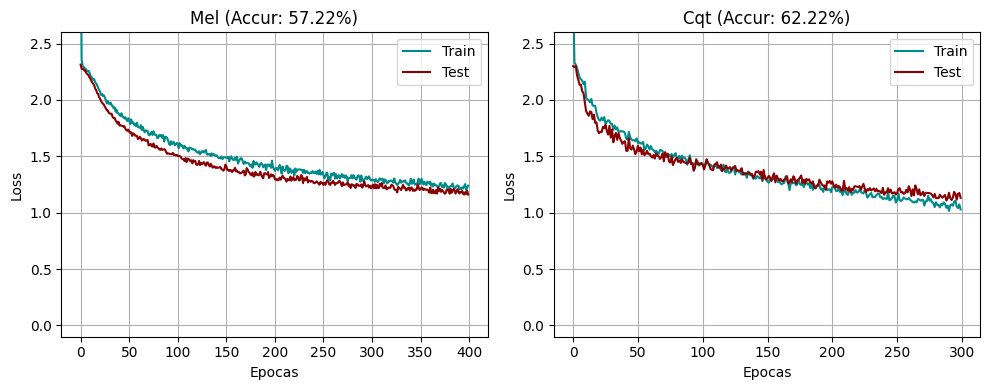

In [9]:
fig, axes = plt.subplots(1, len(train_losses.keys()), figsize=(10, 4))

for i, feat in enumerate(train_losses.keys()):
    plot_losses(train_losses[feat], test_losses[feat], axes[i], title=feat.capitalize(), accuracy=accur[feat])
for ax in axes:
    ax.set_ylim(-0.1, 2.6)
plt.tight_layout()
plt.show()

### CNN1d
Para wav2vec2 y mfcc

In [10]:
class CNN2(nn.Module):
    def __init__(self, feature_len):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=feature_len, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv1d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(512, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # dim x -> (B,80,3001) caso mel

        x = F.leaky_relu(self.conv1(x))
        x = F.max_pool1d(x, kernel_size=3, stride=3)

        x = F.leaky_relu(self.conv2(x))
        x = F.max_pool1d(x, kernel_size=3, stride=3)
        
        x = F.leaky_relu(self.conv3(x))
        x = F.max_pool1d(x, kernel_size=3, stride=3)
        
        x = self.global_pool(x)

        x = x.view(x.size(0), -1) # -> (B, features_len*4)
        x = self.dropout(x)

        x = self.fc1(x)
        x = F.leaky_relu(x)
        
        return self.fc2(x)

In [11]:
# Parametros en general por limitaciones de hardware
BATCH_SIZES = {
    'mel': 32,
    'mfcc': 64,
    'cqt': 64,
    'wav2vec2': 16,
    'EnCodecMAE': 32
}

LEARNING_RATES = {
    'mel': 0.001,
    'mfcc': 0.0039,
    'cqt': 0.0039,
    'wav2vec2': 0.0009,
    'EnCodecMAE': 0.001
}

In [12]:
# Definimos hiperparámetros
NUM_EPOCHS = {
    'mel': 300,
    'mfcc': 150,
    'cqt': 500,
    'wav2vec2': 45,
    'EnCodecMAE': 45
}
params = {
    'num_epoths': NUM_EPOCHS,
    'batch_sizes': BATCH_SIZES,
    'learning_rates': LEARNING_RATES
}

train_losses, test_losses, accur = {}, {}, {} # PARA EL SUMMARY

#### Mel

In [13]:
FEATURE = 'mel'
MODEL = CNN2

train_dataset, test_dataset = get_data_max(FEATURE, Image_dataset)
params['feature_len'] = train_dataset[0]['input_length'][0] # depende del dataset

# Entrenamos el modelo
model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
    model_class=MODEL,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    feature_name=FEATURE, 
    **params
)
accur[FEATURE] = accuracy(model0, test_dataset)

Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[-23.8628,  -9.3174,  -6.4540,  ..., -73.3293, -65.8977, -54.4696],
        [-22.0908,  -4.1262,  -3.4861,  ..., -66.0889, -62.7450, -53.7704],
        [-25.7104,  -4.2807,  -6.4059,  ..., -63.6177, -62.2644, -51.5204],
        ...,
        [-80.0000, -67.7903, -60.2403,  ..., -80.0000, -80.0000, -76.8562],
        [-80.0000, -76.9833, -68.9733,  ..., -80.0000, -80.0000, -76.2964],
        [-80.0000, -80.0000, -80.0000,  ..., -80.0000, -80.0000, -76.2242]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (80, 3001), 'target_length': 10}
--------------------------------------------------
Modelo creado con 590090 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/300
 

In [14]:
#torch.save(model0.state_dict(), "../Models/modelo1_F.pth")

#### Mfcc

In [15]:
FEATURE = 'mfcc'
MODEL = CNN2

train_dataset, test_dataset = get_data_max(FEATURE, Image_dataset)
params['feature_len'] = train_dataset[0]['input_length'][0] # depende del dataset

# Entrenamos el modelo
model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
    model_class=MODEL,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    feature_name=FEATURE, 
    **params
)
accur[FEATURE] = accuracy(model0, test_dataset)

Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[ 1.8167,  1.3974,  0.8455,  ...,  0.7150,  0.6023,  0.3276],
        [-0.6584, -0.9827,  0.1749,  ..., -1.2295, -2.1217, -2.0412],
        [-0.4413,  0.3230, -0.0642,  ..., -2.4076, -2.2594, -1.6155],
        ...,
        [ 0.1937,  0.1937,  0.1937,  ...,  1.6831,  1.6831,  1.6831],
        [-1.7852, -1.7852, -1.7852,  ...,  0.0087,  0.0087,  0.0087],
        [-0.8046, -0.8046, -0.8046,  ..., -0.4890, -0.4890, -0.4890]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (60, 1288), 'target_length': 10}
--------------------------------------------------
Modelo creado con 582410 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/150
  Pérdida Entrenamiento: 2.2595
  Pér

In [16]:
#torch.save(model0.state_dict(), "../Models/modelo1_F.pth")

#### Cqt

In [17]:
FEATURE = 'cqt'
MODEL = CNN2

train_dataset, test_dataset = get_data_max(FEATURE, Image_dataset)
params['feature_len'] = train_dataset[0]['input_length'][0] # depende del dataset

# Entrenamos el modelo
model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
    model_class=MODEL,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    feature_name=FEATURE, 
    **params
)
accur[FEATURE] = accuracy(model0, test_dataset)

Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[-28.6540, -27.9601, -27.5905,  ..., -71.7345, -71.6110, -71.9175],
        [-23.5845, -22.4260, -21.5936,  ..., -73.9189, -74.3702, -74.8183],
        [-20.2321, -18.8270, -17.8161,  ..., -80.0000, -80.0000, -80.0000],
        ...,
        [-46.4007, -34.6097, -42.5703,  ..., -42.2461, -39.9783, -50.7851],
        [-45.0566, -32.9693, -45.5733,  ..., -42.9362, -40.0139, -42.2692],
        [-46.1026, -34.7625, -51.2996,  ..., -42.7572, -53.5620, -45.5680]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (84, 1290), 'target_length': 10}
--------------------------------------------------
Modelo creado con 591626 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/500
 

In [18]:
#torch.save(model0.state_dict(), "../Models/modelo1_F.pth")

#### Wav2Vec2

In [19]:
FEATURE = 'wav2vec2'
MODEL = CNN2

train_dataset, test_dataset = get_data_max(FEATURE, Image_dataset)
params['feature_len'] = train_dataset[0]['input_length'][0] # depende del dataset

# Entrenamos el modelo
model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
    model_class=MODEL,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    feature_name=FEATURE, 
    **params
)
accur[FEATURE] = accuracy(model0, test_dataset)

Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[ 0.1453,  0.1557, -0.0536,  ...,  0.3316,  0.1697,  0.1405],
        [ 0.0935, -0.0723, -0.0536,  ...,  0.0621,  0.1317,  0.0690],
        [ 0.3289,  0.2664, -0.0649,  ...,  0.0504, -0.1395, -0.1283],
        ...,
        [ 0.0308, -0.1482, -0.2585,  ..., -0.1875, -0.3496, -0.3546],
        [ 0.2528,  0.0548, -0.1431,  ..., -0.0203, -0.1249, -0.1942],
        [ 1.8708,  1.7928,  0.9899,  ...,  1.4454,  1.2583,  0.9261]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (768, 1496), 'target_length': 10}
--------------------------------------------------
Modelo creado con 854282 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/45
  Pérdida Entrenamiento: 1.1796
  Pér

In [20]:
#torch.save(model0.state_dict(), "../Models/modelo1_F.pth")

#### EnCodecMAE

In [21]:
FEATURE = 'EnCodecMAE'
MODEL = CNN2

train_dataset, test_dataset = get_data_max(FEATURE, Image_dataset)
params['feature_len'] = train_dataset[0]['input_length'][0] # depende del dataset

# Entrenamos el modelo
model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
    model_class=MODEL,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    feature_name=FEATURE, 
    **params
)
accur[FEATURE] = accuracy(model0, test_dataset)

Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[ 0.1166,  0.3293,  0.2912,  ..., -0.0447, -0.1294, -0.2919],
        [-0.0526, -0.2005, -0.1057,  ..., -0.0665, -0.1994,  0.0229],
        [ 0.2663,  0.2895,  0.2092,  ...,  0.0696,  0.0365,  0.0405],
        ...,
        [-0.2080,  0.0302,  0.2316,  ..., -0.4451, -0.2952, -0.2493],
        [-0.0011,  0.2566,  0.2036,  ...,  0.0012, -0.2762, -0.1896],
        [-0.1978, -0.0559, -0.1534,  ..., -0.1150,  0.1677,  0.0934]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (768, 1031), 'target_length': 10}
--------------------------------------------------
Modelo creado con 854282 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/45
  Pérdida Entrenamiento: 0.7777
  Pér

In [22]:
torch.save(model0.state_dict(), "../Models/modelo_2_cnn2.pth")

#### Summary plot

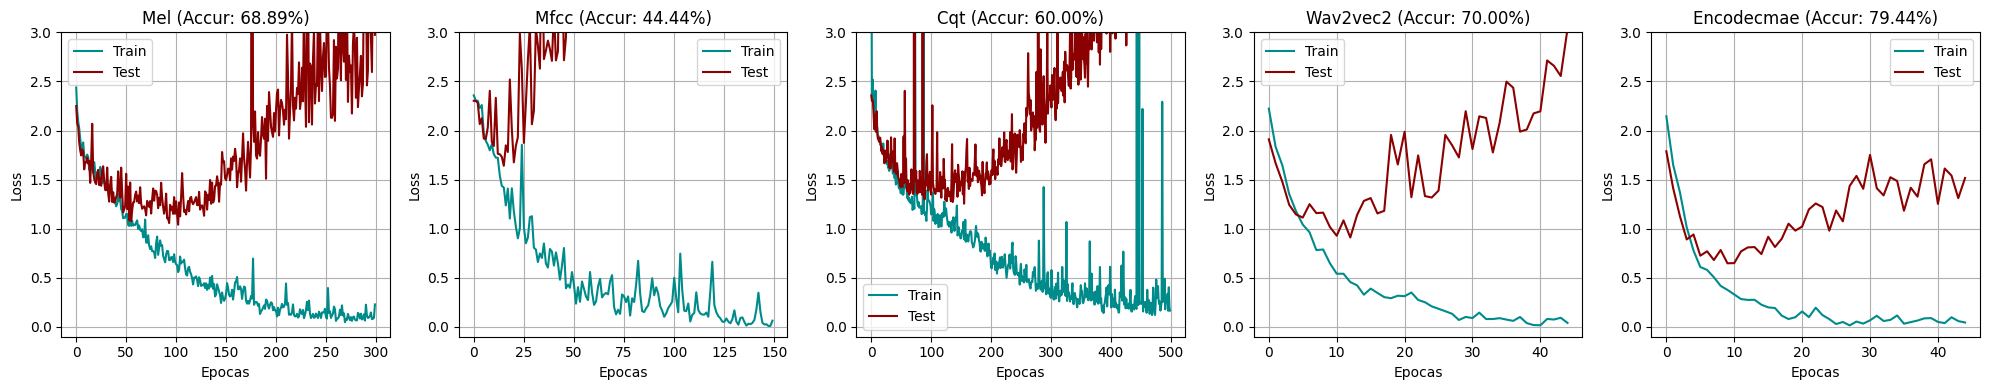

In [23]:
fig, axes = plt.subplots(1, len(train_losses.keys()), figsize=(20, 4))

for i, feat in enumerate(train_losses.keys()):
    plot_losses(train_losses[feat], test_losses[feat], axes[i], title=feat.capitalize(), accuracy=accur[feat])
for ax in axes:
    ax.set_ylim(-0.1, 3)
plt.tight_layout()
plt.show()

Aumentar las epocas

Accuracy de `0.70`, `0.62`, `0.68` y `0.25` respectivamente con epocas [100, 100, 100, 50, .]

### Auxs

In [24]:
X_test = np.load('../Data/X_test_mel.npy') 
X_train = []
print(f"Testeo: {len(X_test)} pares")

test_dataset = Image_dataset(X_test, y_test)
test_dataset[1]

Testeo: 180 pares


{'input': tensor([[-17.9474, -13.7789, -23.3506,  ..., -20.5041, -17.5524, -21.1973],
         [-16.9803, -12.2452, -21.5641,  ..., -21.2815, -14.0695, -21.4555],
         [-17.9659, -16.9527, -22.6373,  ..., -14.2629, -12.4558, -18.5876],
         ...,
         [-72.8470, -80.0000, -80.0000,  ..., -67.5897, -67.9812, -71.3745],
         [-75.1064, -80.0000, -80.0000,  ..., -77.1519, -76.6741, -79.6736],
         [-76.0252, -80.0000, -80.0000,  ..., -80.0000, -80.0000, -80.0000]],
        device='cuda:0'),
 'target': tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.], device='cuda:0'),
 'input_length': (80, 3001),
 'target_length': 10}

In [25]:
conv1 = nn.Conv1d(in_channels=80, out_channels=128, kernel_size=3, stride=1, padding=1).to(device)
conv2 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1).to(device)
conv3 = nn.Conv1d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1).to(device)
global_pool = nn.AdaptiveAvgPool1d(1).to(device)

x = test_dataset[1]['input'].unsqueeze(0)  # batch (1, 80, 3001)
print(f"Input shape: {x.shape}")

Input shape: torch.Size([1, 80, 3001])


In [26]:
y = conv1(x)
y = F.max_pool1d(y, kernel_size=3, stride=3)
y = conv2(y)
y = F.max_pool1d(y, kernel_size=3, stride=3)
y = conv3(y)
y = F.max_pool1d(y, kernel_size=3, stride=3)
y = global_pool(y)
y = y.view(y.size(0), -1)  # Flatten
print(f"Output shape: {y.shape}")

Output shape: torch.Size([1, 512])


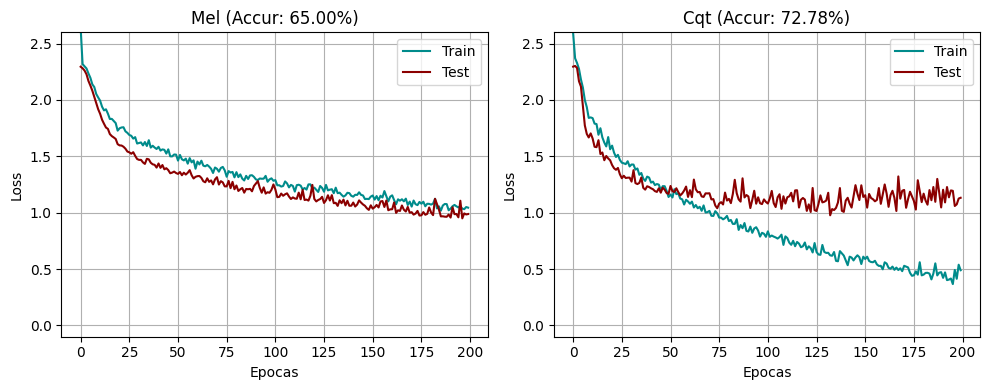

In [ ]:
fig, axes = plt.subplots(1, len(train_losses.keys()), figsize=(10, 4))
# cnn1 ant
for i, feat in enumerate(train_losses.keys()):
    plot_losses(train_losses[feat], test_losses[feat], axes[i], title=feat.capitalize(), accuracy=accur[feat])
for ax in axes:
    ax.set_ylim(-0.1, 2.6)
plt.tight_layout()
plt.show()

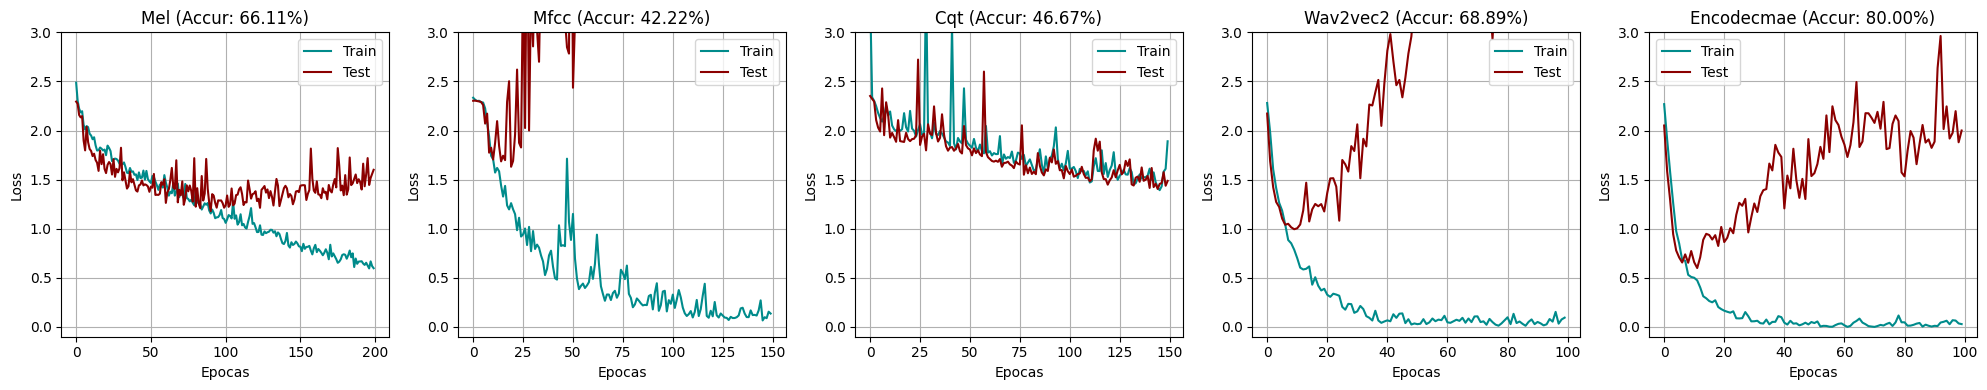

In [ ]:
fig, axes = plt.subplots(1, len(train_losses.keys()), figsize=(20, 4))
# cnn2 ant
for i, feat in enumerate(train_losses.keys()):
    plot_losses(train_losses[feat], test_losses[feat], axes[i], title=feat.capitalize(), accuracy=accur[feat])
for ax in axes:
    ax.set_ylim(-0.1, 3)
plt.tight_layout()
plt.show()

In [ ]:
# Parametros en general por limitaciones de hardware
BATCH_SIZES = {
    'mel': 8,
    'mfcc': 16,
    'cqt': 16,
    'wav2vec2': 4,
    'EnCodecMAE': 8
}

LEARNING_RATES = {
    'mel': 0.0001,#0.001,
    'mfcc': 0.0009,#0.0039,
    'cqt': 0.0009,#0.0039,
    'wav2vec2': 0.00001,#0.0009,
    'EnCodecMAE': 0.0001
}

In [ ]:
class CNN2(nn.Module):
    def __init__(self, feature_len):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=feature_len, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv1d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(512, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # dim x -> (B,80,3001) caso mel

        x = F.leaky_relu(self.conv1(x))
        x = F.max_pool1d(x, kernel_size=3, stride=3)

        x = F.leaky_relu(self.conv2(x))
        x = F.max_pool1d(x, kernel_size=3, stride=3)

        x = F.leaky_relu(self.conv3(x))
        x = F.max_pool1d(x, kernel_size=3, stride=3)

        x = self.global_pool(x)

        x = x.view(x.size(0), -1) # -> (B, features_len*4)
        x = F.leaky_relu(x)
        x = self.dropout(x)

        x = self.fc1(x)
        x = F.leaky_relu(x)
        x = self.dropout(x)

        return self.fc2(x)

In [ ]:
# Definimos hiperparámetros
NUM_EPOCHS = {
    'mel': 400,
    'mfcc': 0,
    'cqt': 300,
    'wav2vec2': 0,
    'EnCodecMAE': 0
}
params = {
    'num_epoths': NUM_EPOCHS,
    'batch_sizes': BATCH_SIZES,
    'learning_rates': LEARNING_RATES
}

train_losses, test_losses, accur = {}, {}, {} # PARA EL SUMMARY

### Modelo 4
cnn1d respecto respecto a la otra orientacion porque no

In [3]:
class CNN2(nn.Module):
    def __init__(self, feature_len):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=feature_len, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv1d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(512, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # dim x -> (B,80,3001) caso mel

        x = F.leaky_relu(self.conv1(x))
        x = F.max_pool1d(x, kernel_size=3, stride=3)

        x = F.leaky_relu(self.conv2(x))
        x = F.max_pool1d(x, kernel_size=3, stride=3)
        
        x = F.leaky_relu(self.conv3(x))
        x = F.max_pool1d(x, kernel_size=3, stride=3)
        
        x = self.global_pool(x)

        x = x.view(x.size(0), -1) # -> (B, features_len*4)
        x = self.dropout(x)

        x = self.fc1(x)
        x = F.leaky_relu(x)
        
        return self.fc2(x)

In [2]:
# Parametros en general por limitaciones de hardware
BATCH_SIZES = {
    'mel': 32,
    'mfcc': 64,
    'cqt': 64,
    'wav2vec2': 16,
    'EnCodecMAE': 32
}

LEARNING_RATES = {
    'mel': 0.0001,
    'mfcc': 0.00039,
    'cqt': 0.00039,
    'wav2vec2': 0.0009,
    'EnCodecMAE': 0.0001
}

In [4]:
# Parametros en general por limitaciones de hardware
BATCH_SIZES = {
    'mel': 32,
    'mfcc': 64,
    'cqt': 64,
    'wav2vec2': 16,
    'EnCodecMAE': 32
}

LEARNING_RATES = {
    'mel': 0.001,
    'mfcc': 0.0039,
    'cqt': 0.0039,
    'wav2vec2': 0.0009,
    'EnCodecMAE': 0.001
}

In [5]:
# Definimos hiperparámetros
NUM_EPOCHS = {
    'mel': 300,
    'mfcc': 150,
    'cqt': 500,
    'wav2vec2': 45,
    'EnCodecMAE': 45
}
params = {
    'num_epoths': NUM_EPOCHS,
    'batch_sizes': BATCH_SIZES,
    'learning_rates': LEARNING_RATES
}

train_losses, test_losses, accur = {}, {}, {} # PARA EL SUMMARY

#### Mel

In [8]:
FEATURE = 'mel'
MODEL = CNN2

train_dataset, test_dataset = get_data_max(FEATURE, Sequence_dataset)
params['feature_len'] = train_dataset[0]['input_length'][0] # depende del dataset

# Entrenamos el modelo
model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
    model_class=MODEL,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    feature_name=FEATURE, 
    **params
)
accur[FEATURE] = accuracy(model0, test_dataset)

Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[-23.8628, -22.0908, -25.7104,  ..., -80.0000, -80.0000, -80.0000],
        [ -9.3174,  -4.1262,  -4.2807,  ..., -67.7903, -76.9833, -80.0000],
        [ -6.4540,  -3.4861,  -6.4059,  ..., -60.2403, -68.9733, -80.0000],
        ...,
        [-73.3293, -66.0889, -63.6177,  ..., -80.0000, -80.0000, -80.0000],
        [-65.8977, -62.7450, -62.2644,  ..., -80.0000, -80.0000, -80.0000],
        [-54.4696, -53.7704, -51.5204,  ..., -76.8562, -76.2964, -76.2242]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (3001, 80), 'target_length': 10}
--------------------------------------------------
Modelo creado con 1711754 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/300


In [9]:
#torch.save(model0.state_dict(), "../Models/modelo1_F.pth")

#### Mfcc

In [10]:
FEATURE = 'mfcc'
MODEL = CNN2

train_dataset, test_dataset = get_data_max(FEATURE, Sequence_dataset)
params['feature_len'] = train_dataset[0]['input_length'][0] # depende del dataset

# Entrenamos el modelo
model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
    model_class=MODEL,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    feature_name=FEATURE, 
    **params
)
accur[FEATURE] = accuracy(model0, test_dataset)

Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[ 1.8167, -0.6584, -0.4413,  ...,  0.1937, -1.7852, -0.8046],
        [ 1.3974, -0.9827,  0.3230,  ...,  0.1937, -1.7852, -0.8046],
        [ 0.8455,  0.1749, -0.0642,  ...,  0.1937, -1.7852, -0.8046],
        ...,
        [ 0.7150, -1.2295, -2.4076,  ...,  1.6831,  0.0087, -0.4890],
        [ 0.6023, -2.1217, -2.2594,  ...,  1.6831,  0.0087, -0.4890],
        [ 0.3276, -2.0412, -1.6155,  ...,  1.6831,  0.0087, -0.4890]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (1288, 60), 'target_length': 10}
--------------------------------------------------
Modelo creado con 1053962 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/150
  Pérdida Entrenamiento: 1.8717
  Pé

In [11]:
#torch.save(model0.state_dict(), "../Models/modelo1_F.pth")

#### Cqt

In [12]:
FEATURE = 'cqt'
MODEL = CNN2

train_dataset, test_dataset = get_data_max(FEATURE, Sequence_dataset)
params['feature_len'] = train_dataset[0]['input_length'][0] # depende del dataset

# Entrenamos el modelo
model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
    model_class=MODEL,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    feature_name=FEATURE, 
    **params
)
accur[FEATURE] = accuracy(model0, test_dataset)

Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[-28.6540, -23.5845, -20.2321,  ..., -46.4007, -45.0566, -46.1026],
        [-27.9601, -22.4260, -18.8270,  ..., -34.6097, -32.9693, -34.7625],
        [-27.5905, -21.5936, -17.8161,  ..., -42.5703, -45.5733, -51.2996],
        ...,
        [-71.7345, -73.9189, -80.0000,  ..., -42.2461, -42.9362, -42.7572],
        [-71.6110, -74.3702, -80.0000,  ..., -39.9783, -40.0139, -53.5620],
        [-71.9175, -74.8183, -80.0000,  ..., -50.7851, -42.2692, -45.5680]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (1290, 84), 'target_length': 10}
--------------------------------------------------
Modelo creado con 1054730 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/500


In [13]:
#torch.save(model0.state_dict(), "../Models/modelo1_F.pth")

#### Wav2Vec2

In [14]:
FEATURE = 'wav2vec2'
MODEL = CNN2

train_dataset, test_dataset = get_data_max(FEATURE, Sequence_dataset)
params['feature_len'] = train_dataset[0]['input_length'][0] # depende del dataset

# Entrenamos el modelo
model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
    model_class=MODEL,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    feature_name=FEATURE, 
    **params
)
accur[FEATURE] = accuracy(model0, test_dataset)

Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[ 0.1453,  0.0935,  0.3289,  ...,  0.0308,  0.2528,  1.8708],
        [ 0.1557, -0.0723,  0.2664,  ..., -0.1482,  0.0548,  1.7928],
        [-0.0536, -0.0536, -0.0649,  ..., -0.2585, -0.1431,  0.9899],
        ...,
        [ 0.3316,  0.0621,  0.0504,  ..., -0.1875, -0.0203,  1.4454],
        [ 0.1697,  0.1317, -0.1395,  ..., -0.3496, -0.1249,  1.2583],
        [ 0.1405,  0.0690, -0.1283,  ..., -0.3546, -0.1942,  0.9261]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (1496, 768), 'target_length': 10}
--------------------------------------------------
Modelo creado con 1133834 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/45
  Pérdida Entrenamiento: 2.1628
  Pé

In [15]:
#torch.save(model0.state_dict(), "../Models/modelo1_F.pth")

#### EnCodecMAE

In [16]:
FEATURE = 'EnCodecMAE'
MODEL = CNN2

train_dataset, test_dataset = get_data_max(FEATURE, Sequence_dataset)
params['feature_len'] = train_dataset[0]['input_length'][0] # depende del dataset

# Entrenamos el modelo
model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
    model_class=MODEL,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    feature_name=FEATURE, 
    **params
)
accur[FEATURE] = accuracy(model0, test_dataset)

Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[ 0.1166, -0.0526,  0.2663,  ..., -0.2080, -0.0011, -0.1978],
        [ 0.3293, -0.2005,  0.2895,  ...,  0.0302,  0.2566, -0.0559],
        [ 0.2912, -0.1057,  0.2092,  ...,  0.2316,  0.2036, -0.1534],
        ...,
        [-0.0447, -0.0665,  0.0696,  ..., -0.4451,  0.0012, -0.1150],
        [-0.1294, -0.1994,  0.0365,  ..., -0.2952, -0.2762,  0.1677],
        [-0.2919,  0.0229,  0.0405,  ..., -0.2493, -0.1896,  0.0934]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (1031, 768), 'target_length': 10}
--------------------------------------------------
Modelo creado con 955274 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/45
  Pérdida Entrenamiento: 2.0382
  Pér

In [17]:
torch.save(model0.state_dict(), "../Models/modelo_2_cnn2.pth")

#### Summary plot

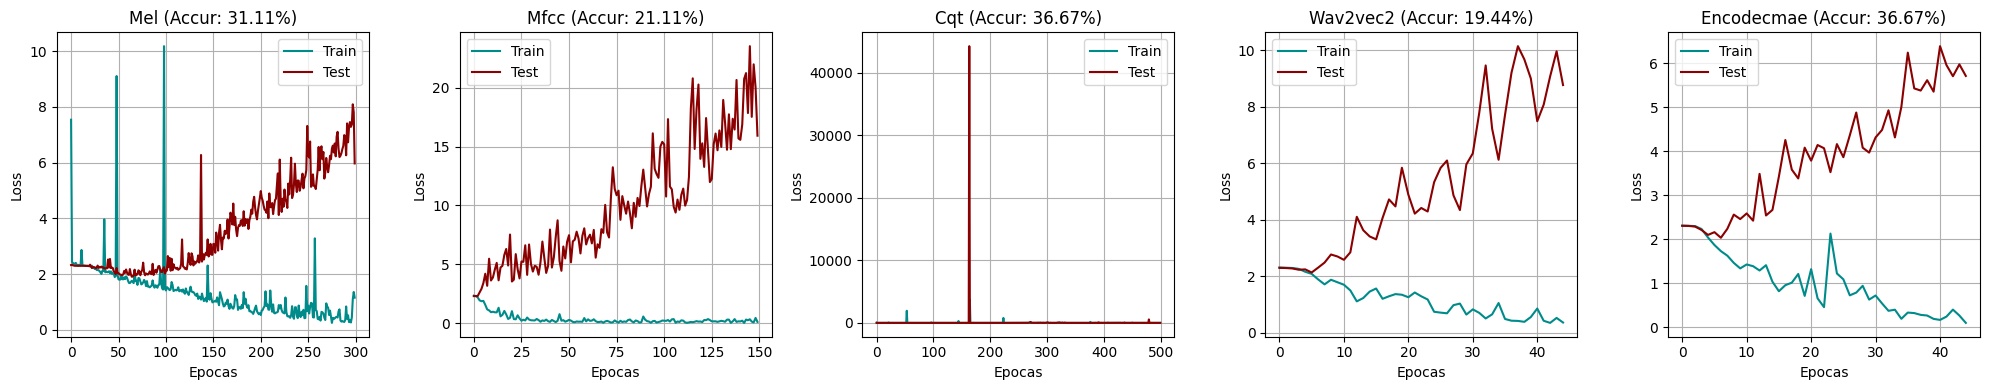

In [18]:
fig, axes = plt.subplots(1, len(train_losses.keys()), figsize=(20, 4))

for i, feat in enumerate(train_losses.keys()):
    plot_losses(train_losses[feat], test_losses[feat], axes[i], title=feat.capitalize(), accuracy=accur[feat])
#for ax in axes:
#    ax.set_ylim(-0.1, 3)
plt.tight_layout()
plt.show()

### Modelo 5
sin global avg pool

In [7]:
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from setup import train, device, train_test_split_path, accuracy, plot_losses, Image_dataset, get_data_max, train_pro_max, Sequence_dataset
X_train_path, X_test_path, X_eval_path, y_train, y_test, y_eval = train_test_split_path()

In [8]:
class EEGSpectrogramCNN(nn.Module):
    def __init__(self, T, feature_len, num_classes=10):
        """
        Args:
          T (int):   number of time-steps in your spectrogram
          F (int):   number of frequency bins (feature_len)
          num_classes (int):  e.g. 2 for left vs. right
        """
        super().__init__()
        self.T, self.F = T, feature_len

        # ---- conv + pool 1 ----
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=30,
            kernel_size=(15, 1),
            padding=(7, 0)       # keep T dim the same
        )
        self.pool1 = nn.MaxPool2d(kernel_size=(9, 1), stride=(9,1))

        # ---- conv + pool 2 ----
        self.conv2 = nn.Conv2d(
            in_channels=30,
            out_channels=30,
            kernel_size=(1, 6),
            padding=(0, 3)       # keep F dim the same
        )
        self.pool2 = nn.MaxPool2d(kernel_size=(1, 2), stride=(1,2))

        # compute output dims after pooling:
        #   T1 = ceil(T / 9)
        #   F1 = ceil(F / 2)
        T1 = self.T // 9
        F1 = self.F // 2

        flat_dim = 30 * T1 * F1
        self.classifier = nn.Linear(flat_dim, num_classes)
        self.dropout = nn.Dropout(0.5)
    def forward(self, x):
        """
        Args:
          x: Tensor of shape (batch, 1, T, F)
        Returns:
          logits: Tensor of shape (batch, num_classes)
        """
        x = x.unsqueeze(1) # (batch, 1, T,   F)
        # conv+relu → pool
        x = F.relu(self.conv1(x))  # (batch,30, T,   F)
        x = self.pool1(x)          # (batch,30, T1,  F)

        x = F.relu(self.conv2(x))  # (batch,30, T1,  F)
        x = self.pool2(x)          # (batch,30, T1,  F1)

        # flatten all but batch
        x = x.view(x.size(0), -1)  # (batch, 30*T1*F1)
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits


In [9]:
# Parametros en general por limitaciones de hardware
BATCH_SIZES = {
    'mel': 30,
    'mfcc': 60,#muy alto para memoria
    'cqt': 60,#idem
    'wav2vec2': 8,
    'EnCodecMAE': 16
}

LEARNING_RATES = {
    'mel': 0.0001,
    'mfcc': 0.001,
    'cqt': 0.001,
    'wav2vec2': 0.00001,
    'EnCodecMAE': 0.001
}

In [10]:
# Definimos hiperparámetros
NUM_EPOCHS = {
    'mel': 30,
    'mfcc': 30,
    'cqt': 30,
    'wav2vec2': 30,
    'EnCodecMAE': 30
}
params = {
    'num_epoths': NUM_EPOCHS,
    'batch_sizes': BATCH_SIZES,
    'learning_rates': LEARNING_RATES
}

train_losses, test_losses, accur = {}, {}, {} # PARA EL SUMMARY

In [11]:
MODEL = EEGSpectrogramCNN
for FEATURE in ['mel', 'cqt']:
    train_dataset, test_dataset = get_data_max(FEATURE, Sequence_dataset)
    params['T'] = train_dataset[0]['input_length'][0] # depende del dataset
    params['feature_len'] = train_dataset[0]['input_length'][1] # depende del dataset

    # Entrenamos el modelo
    model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
        model_class=MODEL,
        train_dataset=train_dataset,
        test_dataset=test_dataset,
        feature_name=FEATURE, 
        **params
    )
    accur[FEATURE] = accuracy(model0, test_dataset)
    del train_dataset, test_dataset, model0
    torch.cuda.empty_cache()
    gc.collect()


Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[-23.8628, -22.0908, -25.7104,  ..., -80.0000, -80.0000, -80.0000],
        [ -9.3174,  -4.1262,  -4.2807,  ..., -67.7903, -76.9833, -80.0000],
        [ -6.4540,  -3.4861,  -6.4059,  ..., -60.2403, -68.9733, -80.0000],
        ...,
        [-73.3293, -66.0889, -63.6177,  ..., -80.0000, -80.0000, -80.0000],
        [-65.8977, -62.7450, -62.2644,  ..., -80.0000, -80.0000, -80.0000],
        [-54.4696, -53.7704, -51.5204,  ..., -76.8562, -76.2964, -76.2242]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (3001, 80), 'target_length': 10}
--------------------------------------------------
Modelo creado con 4001920 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/30
 

#### Summary plot

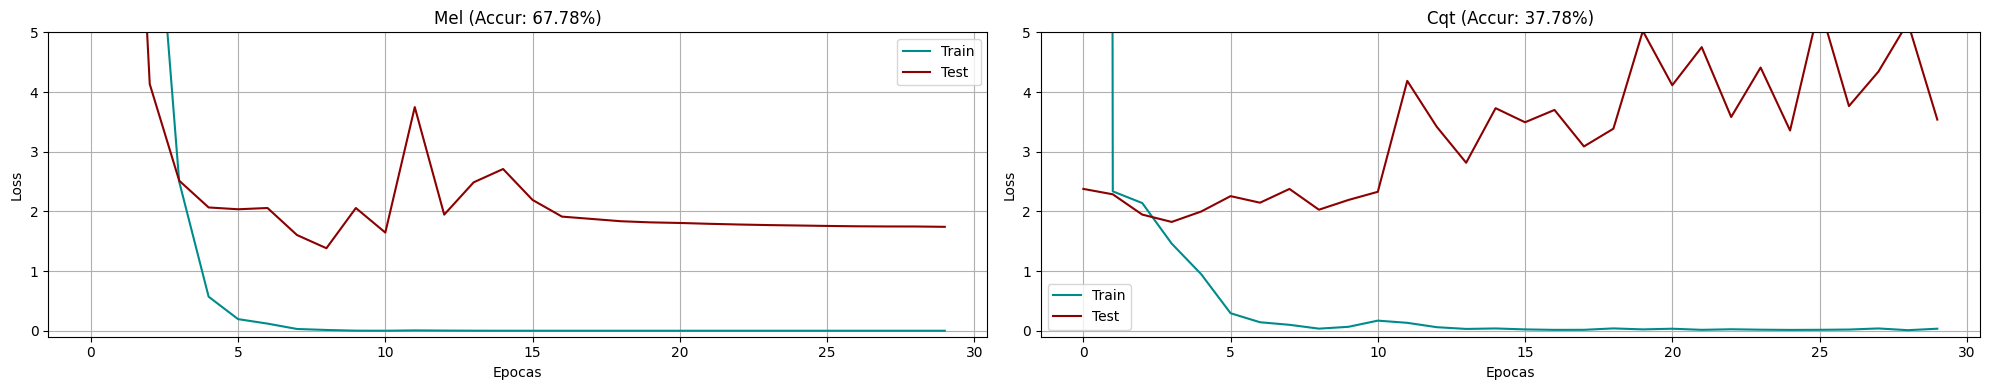

In [12]:
fig, axes = plt.subplots(1, len(train_losses.keys()), figsize=(20, 4))

for i, feat in enumerate(train_losses.keys()):
    plot_losses(train_losses[feat], test_losses[feat], axes[i], title=feat.capitalize(), accuracy=accur[feat])
for ax in axes:
    ax.set_ylim(-0.1, 5)
plt.tight_layout()
plt.show()

### Modelo 6
con global avg pool

In [ ]:
class EEGSpectrogramCNN(nn.Module):
    def __init__(self, T, feature_len, num_classes=10):
        """
        Args:
          T (int):   number of time-steps in your spectrogram
          F (int):   number of frequency bins (feature_len)
          num_classes (int):  e.g. 2 for left vs. right
        """
        super().__init__()
        self.T, self.F = T, feature_len

        # ---- conv + pool 1 ----
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=30,
            kernel_size=(15, 1),
            padding=(7, 0)
        )
        self.pool1 = nn.MaxPool2d(kernel_size=(9, 1), stride=(9,1))

        # ---- conv + pool 2 ----
        self.conv2 = nn.Conv2d(
            in_channels=30,
            out_channels=30,
            kernel_size=(1, 6),
            padding=(0, 3)
        )
        self.pool2 = nn.MaxPool2d(kernel_size=(1, 2), stride=(1,2))

        flat_dim = 30
        self.classifier = nn.Linear(flat_dim, num_classes)
        self.dropout = nn.Dropout(0.5)
        self.global_pool = nn.AdaptiveAvgPool2d((1,1))

    def forward(self, x):
        """
        Args:
          x: Tensor of shape (batch, 1, T, F)
        Returns:
          logits: Tensor of shape (batch, num_classes)
        """
        x = x.unsqueeze(1) # (batch, 1, T,   F)
        # conv+relu → pool
        x = F.relu(self.conv1(x))  # (batch,30, T,   F)
        x = self.pool1(x)          # (batch,30, T1,  F)

        x = F.relu(self.conv2(x))  # (batch,30, T1,  F)
        x = self.pool2(x)          # (batch,30, T1,  F1)
        x = self.global_pool(x)
        
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits


In [17]:
# Definimos hiperparámetros
NUM_EPOCHS = {
    'mel': 50,
    'mfcc': 50,
    'cqt': 50,
    'wav2vec2': 50,
    'EnCodecMAE': 50
}
params = {
    'num_epoths': NUM_EPOCHS,
    'batch_sizes': BATCH_SIZES,
    'learning_rates': LEARNING_RATES
}

train_losses, test_losses, accur = {}, {}, {} # PARA EL SUMMARY

In [18]:
MODEL = EEGSpectrogramCNN
for FEATURE in ['mel', 'cqt']:
    train_dataset, test_dataset = get_data_max(FEATURE, Sequence_dataset)
    params['T'] = train_dataset[0]['input_length'][0] # depende del dataset
    params['feature_len'] = train_dataset[0]['input_length'][1] # depende del dataset

    # Entrenamos el modelo
    model0, train_losses[FEATURE], test_losses[FEATURE] = train_pro_max(
        model_class=MODEL,
        train_dataset=train_dataset,
        test_dataset=test_dataset,
        feature_name=FEATURE, 
        **params
    )
    accur[FEATURE] = accuracy(model0, test_dataset)
    del train_dataset, test_dataset, model0
    torch.cuda.empty_cache()
    gc.collect()


Entrenamiento: 719 pares
Testeo: 180 pares
--------------------------------------------------
Primer elemento del dataset de entrenamiento: {'input': tensor([[-23.8628, -22.0908, -25.7104,  ..., -80.0000, -80.0000, -80.0000],
        [ -9.3174,  -4.1262,  -4.2807,  ..., -67.7903, -76.9833, -80.0000],
        [ -6.4540,  -3.4861,  -6.4059,  ..., -60.2403, -68.9733, -80.0000],
        ...,
        [-73.3293, -66.0889, -63.6177,  ..., -80.0000, -80.0000, -80.0000],
        [-65.8977, -62.7450, -62.2644,  ..., -80.0000, -80.0000, -80.0000],
        [-54.4696, -53.7704, -51.5204,  ..., -76.8562, -76.2964, -76.2242]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'), 'input_length': (3001, 80), 'target_length': 10}
--------------------------------------------------
Modelo creado con 6220 parámetros
--------------------------------------------------
Iniciando entrenamiento...
--------------------------------------------------
Época 5/50
  Pé

#### Summary plot

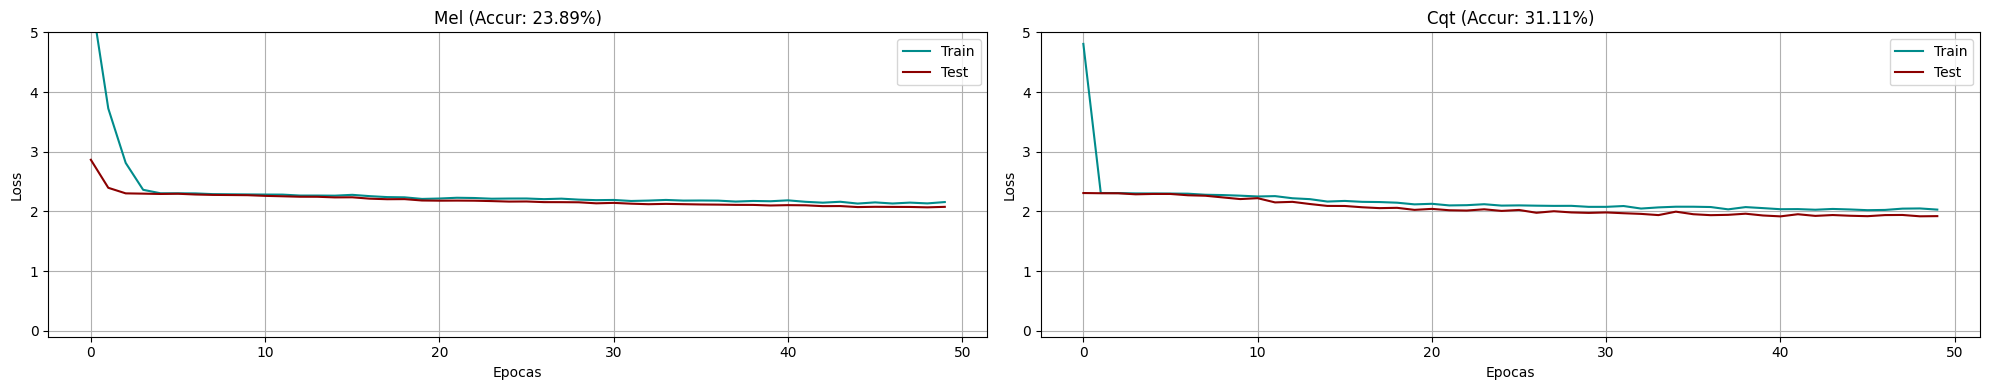

In [19]:
fig, axes = plt.subplots(1, len(train_losses.keys()), figsize=(20, 4))

for i, feat in enumerate(train_losses.keys()):
    plot_losses(train_losses[feat], test_losses[feat], axes[i], title=feat.capitalize(), accuracy=accur[feat])
for ax in axes:
    ax.set_ylim(-0.1, 5)
plt.tight_layout()
plt.show()